In [1]:
import sys
import os

# Fix path to backend root
backend_path = os.path.abspath(
    os.path.join(os.getcwd(), '..', '..')
)
if backend_path not in sys.path:
    sys.path.insert(0, backend_path)

print(f"Backend path: {backend_path}")
print(f"Path exists: {os.path.exists(backend_path)}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
print('Libraries loaded ✅')

Backend path: /home/rishabh/Documents/AI Projects
Path exists: True
Libraries loaded ✅


In [2]:
from ml.src.train import generate_training_data

df = generate_training_data()
print(f'Dataset shape: {df.shape}')
df.head()

/home/rishabh/.local/lib/python3.10/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/rishabh/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):


Dataset shape: (12, 3)


,resume,job,label
0,5 years Python FastAPI PostgreSQL Docker AWS R...,Python developer FastAPI PostgreSQL Docker AWS,1
1,React JavaScript TypeScript NodeJS MongoDB 3 y...,Frontend developer React JavaScript TypeScript,1
2,Java Spring Boot Kubernetes microservices 7 years,Java backend Spring Boot Kubernetes microservices,1
3,Data scientist Python pandas numpy scikit-lear...,Data scientist machine learning Python scikit-...,1
4,DevOps AWS Docker Kubernetes Jenkins Linux 6 y...,DevOps engineer AWS Docker Kubernetes Jenkins,1


In [3]:
from app.ml.preprocessing.skill_extractor import extract_skills
from app.ml.preprocessing.text_cleaner import extract_experience_years

df['resume_skills'] = df['resume'].apply(extract_skills)
df['job_skills'] = df['job'].apply(extract_skills)
df['resume_skill_count'] = df['resume_skills'].apply(len)
df['job_skill_count'] = df['job_skills'].apply(len)
df['experience_years'] = df['resume'].apply(extract_experience_years)

print(df[['resume_skill_count','job_skill_count','experience_years','label']].describe())

       resume_skill_count  job_skill_count  experience_years      label
count           12.000000        12.000000              12.0  12.000000
mean             2.916667         3.833333               0.0   0.500000
std              2.108784         0.717741               0.0   0.522233
min              0.000000         3.000000               0.0   0.000000
25%              1.500000         3.000000               0.0   0.000000
50%              3.500000         4.000000               0.0   0.500000
75%              4.250000         4.000000               0.0   1.000000
max              6.000000         5.000000               0.0   1.000000


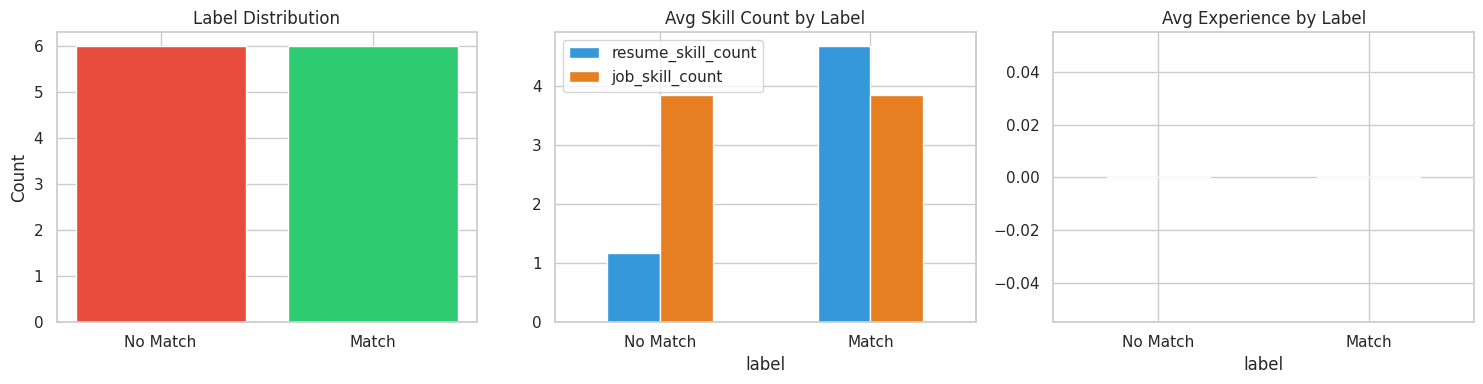

EDA Complete ✅


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

counts = df['label'].value_counts()
axes[0].bar(['No Match','Match'], counts.values, color=['#e74c3c','#2ecc71'])
axes[0].set_title('Label Distribution')
axes[0].set_ylabel('Count')

df.groupby('label')[['resume_skill_count','job_skill_count']].mean().plot(
    kind='bar', ax=axes[1], color=['#3498db','#e67e22']
)
axes[1].set_title('Avg Skill Count by Label')
axes[1].set_xticklabels(['No Match','Match'], rotation=0)

df.groupby('label')['experience_years'].mean().plot(
    kind='bar', ax=axes[2], color=['#e74c3c','#2ecc71']
)
axes[2].set_title('Avg Experience by Label')
axes[2].set_xticklabels(['No Match','Match'], rotation=0)

plt.tight_layout()
plt.show()
print('EDA Complete ✅')